**Не зафиксировал объективно, повлияля ли видеокарта на скорость обчения. Поэтому лучше перед выполнением ячеек всё же переключиться на графический процессор.**

# **Практическое занятие: RNN, LSTM и GRU**

В этом блокноте мы проведём эксперименты с рекуррентными сетями, чтобы на практике увидеть, как они справляются с долгосрочными зависимостями и как LSTM/GRU решают проблему затухающих градиентов. Мы используем PyTorch и Google Colab.

**План практики:**
1. **Adding problem** – синтетическая задача, требующая запоминания информации на большом расстоянии. Сравним vanilla RNN, LSTM и GRU, визуализируем градиенты.
2. **Классификация тональности на русском языке** – используем датасет RuSentiment, построим BiLSTM, сравним однонаправленную и двунаправленную модели, визуализируем скрытые состояния через t-SNE.

👉 *Инструкция:* Запускайте ячейки последовательно, меняйте гиперпараметры, где предложено, и отвечайте на вопросы для интерпретации.

## **1. Установка и импорт библиотек**

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer
from tqdm import tqdm
import random
import warnings
warnings.filterwarnings('ignore')

# Для воспроизводимости
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## **2. Эксперимент 1: Adding problem (задача на долгосрочные зависимости)**

**Описание задачи:** Даётся последовательность случайных чисел $x_1, \dots, x_T$ (обычно T=100) и два индекса $i$ и $j$ (первый в первой половине, второй – во второй). Цель – рассчитать сумму $x_i + x_j$. Модель должна запомнить значения на больших расстояниях.

Мы сравним три модели: **vanilla RNN**, **LSTM**, **GRU**. Будем отслеживать:
- потери на валидации
- нормы градиентов для разных шагов времени (чтобы увидеть затухание)

Здесь формируются numpy вектора на выходе.

In [20]:
def generate_adding_problem_data(num_samples, seq_len=100):
    """
    Генерирует синтетический датасет для adding problem.
    Возвращает: X (num_samples, seq_len, 2) – два канала: значение и индикатор позиции,
                y (num_samples) – сумма двух выбранных чисел.
    """
    X = np.random.uniform(0, 1, (num_samples, seq_len, 2)).astype(np.float32)
    y = np.zeros((num_samples,), dtype=np.float32)
    for i in range(num_samples):
        # выбираем случайные индексы: первый в первой половине, второй – во второй
        idx1 = np.random.randint(0, seq_len // 2)
        idx2 = np.random.randint(seq_len // 2, seq_len)
        X[i, idx1, 1] = 1.0
        X[i, idx2, 1] = 1.0
        y[i] = X[i, idx1, 0] + X[i, idx2, 0]
    return X, y

# Генерируем train и val
seq_len = 50
train_X, train_y = generate_adding_problem_data(5000, seq_len)
val_X, val_y = generate_adding_problem_data(1000, seq_len)

print(f'Train shape: {train_X.shape}, Val shape: {val_X.shape}')

Train shape: (5000, 50, 2), Val shape: (1000, 50, 2)


Здесь из numpy векторов преобразование в тензоры pytorch и j,]trns lkz elj,cndf gjkextybz byajhvfwbb/

In [21]:
class AddingDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X)
        self.y = torch.tensor(y).unsqueeze(1)  # для MSE функция в PyTorch, которая добавляет новое измерение размером 1 к тензору в указанной позиции (индекс измерения)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = AddingDataset(train_X, train_y)
val_dataset = AddingDataset(val_X, val_y)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

Построение классической рекуррентной нейросети

In [5]:
class VanillaRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        # Если batch_first = True, то входные и выходные тензоры имеют форму (batch_size, seq_len, input_size)
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True, nonlinearity='tanh')
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.rnn(x)  # out: (batch, seq_len, hidden)
        out = self.fc(out[:, -1, :])  # используем последний скрытый
        return out

In [6]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

In [7]:
class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.gru(x)
        out = self.fc(out[:, -1, :])
        return out

Реализация цикла обучения одной сети. Запоминает нормы градиентов

In [24]:
def train_model(model, train_loader, val_loader, epochs=20, lr=0.01, clip=1.0):
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    train_losses, val_losses = [], []
    grad_norms = []  # для отслеживания норм градиентов (по эпохам)

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            loss.backward()
            # Обрезка градиентов
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
            # Сохраняем норму градиентов для анализа
            total_norm = 0.0
            for p in model.parameters():
                if p.grad is not None:
                    param_norm = p.grad.data.norm(2)
                    total_norm += param_norm.item() ** 2
            total_norm = total_norm ** 0.5
            grad_norms.append(total_norm)
            optimizer.step()
            total_loss += loss.item()
        train_losses.append(total_loss / len(train_loader))

        # Валидация
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                pred = model(X_batch)
                loss = criterion(pred, y_batch)
                val_loss += loss.item()
        val_losses.append(val_loss / len(val_loader))
        if (epoch+1) % 5 == 0:
            print(f'Epoch {epoch+1}: train_loss={train_losses[-1]:.4f}, val_loss={val_losses[-1]:.4f}')

    return train_losses, val_losses, grad_norms

Собственно обучение трёх сетей.
Осторожно! Работает долго.

In [25]:
input_size = 2
hidden_size = 128
output_size = 1
epochs = 100

print("Training Vanilla RNN...")
rnn_model = VanillaRNN(input_size, hidden_size, output_size)
rnn_train_loss, rnn_val_loss, rnn_grads = train_model(rnn_model, train_loader, val_loader, epochs=epochs)

print("\nTraining LSTM...")
lstm_model = LSTMModel(input_size, hidden_size, output_size)
lstm_train_loss, lstm_val_loss, lstm_grads = train_model(lstm_model, train_loader, val_loader, epochs=epochs)

print("\nTraining GRU...")
gru_model = GRUModel(input_size, hidden_size, output_size)
gru_train_loss, gru_val_loss, gru_grads = train_model(gru_model, train_loader, val_loader, epochs=epochs)

Training Vanilla RNN...
Epoch 5: train_loss=0.2123, val_loss=0.2786
Epoch 10: train_loss=0.2005, val_loss=0.1711
Epoch 15: train_loss=0.1963, val_loss=0.2000
Epoch 20: train_loss=0.2078, val_loss=0.3193
Epoch 25: train_loss=0.2068, val_loss=0.1723
Epoch 30: train_loss=0.2494, val_loss=0.1707
Epoch 35: train_loss=0.2002, val_loss=0.1834
Epoch 40: train_loss=0.2181, val_loss=0.2538
Epoch 45: train_loss=0.2023, val_loss=0.1823
Epoch 50: train_loss=0.2649, val_loss=0.1931
Epoch 55: train_loss=0.1925, val_loss=0.3906
Epoch 60: train_loss=0.2029, val_loss=0.1715
Epoch 65: train_loss=0.2244, val_loss=0.1821
Epoch 70: train_loss=0.2000, val_loss=0.1933
Epoch 75: train_loss=0.1880, val_loss=0.1717
Epoch 80: train_loss=0.2006, val_loss=0.2031
Epoch 85: train_loss=0.2522, val_loss=0.1728
Epoch 90: train_loss=0.2114, val_loss=0.1720
Epoch 95: train_loss=0.2055, val_loss=0.1812
Epoch 100: train_loss=0.1945, val_loss=0.1707

Training LSTM...
Epoch 5: train_loss=0.1724, val_loss=0.1785
Epoch 10: trai

### **2.1. Визуализация результатов**

В нормах градиентов итерация - это эпоха + номер батча внутри эпохи.

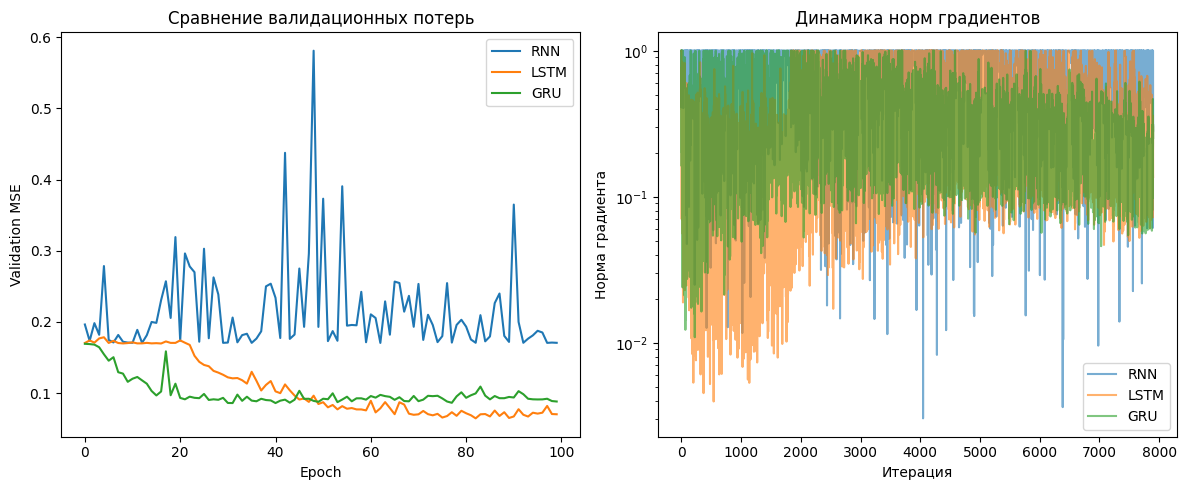

In [26]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(rnn_val_loss, label='RNN')
plt.plot(lstm_val_loss, label='LSTM')
plt.plot(gru_val_loss, label='GRU')
plt.xlabel('Epoch')
plt.ylabel('Validation MSE')
plt.legend()
plt.title('Сравнение валидационных потерь')

plt.subplot(1,2,2)
plt.plot(rnn_grads[:len(rnn_grads)], label='RNN', alpha=0.6)
plt.plot(lstm_grads[:len(lstm_grads)], label='LSTM', alpha=0.6)
plt.plot(gru_grads[:len(gru_grads)], label='GRU', alpha=0.6)
plt.xlabel('Итерация')
plt.ylabel('Норма градиента')
plt.yscale('log')
plt.legend()
plt.title('Динамика норм градиентов')
plt.tight_layout()
plt.show()

Теоретически надо было бы построить график такого плана:

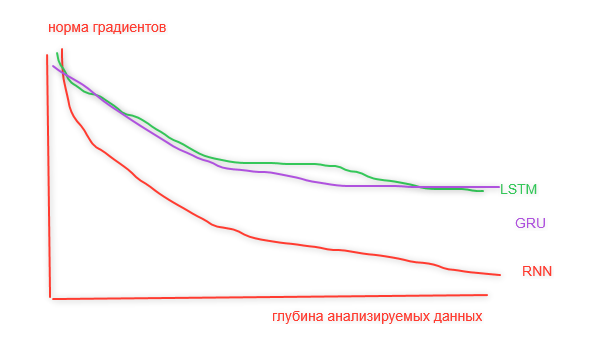

**Задание для интерпретации:**
1. Какая модель показала наименьшую ошибку на валидации? Почему, на ваш взгляд?
2. Посмотрите на график норм градиентов. Для какой модели градиенты быстрее всего уменьшаются? Связано ли это с проблемой затухания?
3. Попробуйте увеличить длину последовательности до 200 (сгенерируйте новые данные) и повторите обучение (измените `seq_len=200` в ячейке генерации). Что изменилось?

В итоге нименьшую ошибку показала lstm потому что в неё вместе с gru встроен механизм, позволяющих избежать проблемы затухающих градиентов для длинных полследовательностей

Градиент не уменьшается ни у какой модели, он наоборот пытается взорваться, норма градиента не отражает проблему затахающего градиента, потому что считается по всей модели сразу

Как видно ниже, LSTM дольше находила нужный локальный минимум лосс функции, но потом обошла GRU

In [ ]:
def generate_adding_problem_data(num_samples, seq_len=100):
    """
    Генерирует синтетический датасет для adding problem.
    Возвращает: X (num_samples, seq_len, 2) – два канала: значение и индикатор позиции,
                y (num_samples) – сумма двух выбранных чисел.
    """
    X = np.random.uniform(0, 1, (num_samples, seq_len, 2)).astype(np.float32)
    y = np.zeros((num_samples,), dtype=np.float32)
    for i in range(num_samples):
        # выбираем случайные индексы: первый в первой половине, второй – во второй
        idx1 = np.random.randint(0, seq_len // 2)
        idx2 = np.random.randint(seq_len // 2, seq_len)
        X[i, idx1, 1] = 1.0
        X[i, idx2, 1] = 1.0
        y[i] = X[i, idx1, 0] + X[i, idx2, 0]
    return X, y

# Генерируем train и val
seq_len = 200
train_X, train_y = generate_adding_problem_data(5000, seq_len)
val_X, val_y = generate_adding_problem_data(1000, seq_len)

print(f'Train shape: {train_X.shape}, Val shape: {val_X.shape}')

Train shape: (5000, 50, 2), Val shape: (1000, 50, 2)


In [28]:
class AddingDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X)
        self.y = torch.tensor(y).unsqueeze(1)  # для MSE функция в PyTorch, которая добавляет новое измерение размером 1 к тензору в указанной позиции (индекс измерения)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = AddingDataset(train_X, train_y)
val_dataset = AddingDataset(val_X, val_y)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

In [29]:
input_size = 2
hidden_size = 128
output_size = 1
epochs = 100

print("Training Vanilla RNN...")
rnn_model = VanillaRNN(input_size, hidden_size, output_size)
rnn_train_loss, rnn_val_loss, rnn_grads = train_model(rnn_model, train_loader, val_loader, epochs=epochs)

print("\nTraining LSTM...")
lstm_model = LSTMModel(input_size, hidden_size, output_size)
lstm_train_loss, lstm_val_loss, lstm_grads = train_model(lstm_model, train_loader, val_loader, epochs=epochs)

print("\nTraining GRU...")
gru_model = GRUModel(input_size, hidden_size, output_size)
gru_train_loss, gru_val_loss, gru_grads = train_model(gru_model, train_loader, val_loader, epochs=epochs)

Training Vanilla RNN...
Epoch 5: train_loss=0.1805, val_loss=0.1642
Epoch 10: train_loss=0.2016, val_loss=0.2119
Epoch 15: train_loss=0.2166, val_loss=0.1761
Epoch 20: train_loss=0.2032, val_loss=0.1948
Epoch 25: train_loss=0.1742, val_loss=0.2458
Epoch 30: train_loss=0.2108, val_loss=0.2319
Epoch 35: train_loss=0.2065, val_loss=0.1694
Epoch 40: train_loss=0.1988, val_loss=0.1716
Epoch 45: train_loss=0.1837, val_loss=0.1652
Epoch 50: train_loss=0.1869, val_loss=0.3053
Epoch 55: train_loss=0.1960, val_loss=0.1643
Epoch 60: train_loss=0.1954, val_loss=0.4188
Epoch 65: train_loss=0.2064, val_loss=0.3057
Epoch 70: train_loss=0.2088, val_loss=0.2423
Epoch 75: train_loss=0.2412, val_loss=0.2181
Epoch 80: train_loss=0.2006, val_loss=0.2090
Epoch 85: train_loss=0.1888, val_loss=0.1690
Epoch 90: train_loss=0.2133, val_loss=0.1654
Epoch 95: train_loss=0.2205, val_loss=0.1870
Epoch 100: train_loss=0.2028, val_loss=0.2050

Training LSTM...
Epoch 5: train_loss=0.1677, val_loss=0.1644
Epoch 10: trai

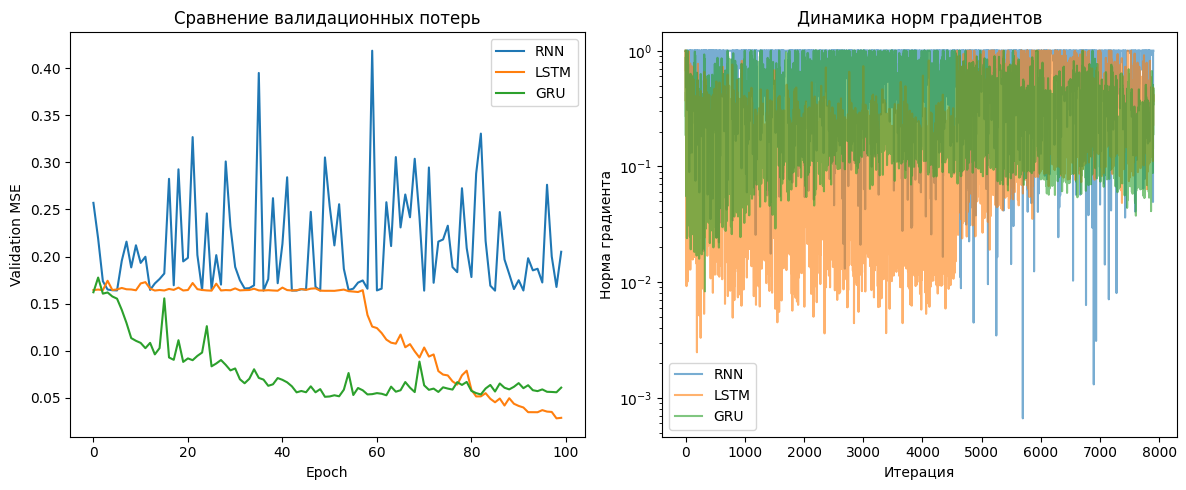

In [30]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(rnn_val_loss, label='RNN')
plt.plot(lstm_val_loss, label='LSTM')
plt.plot(gru_val_loss, label='GRU')
plt.xlabel('Epoch')
plt.ylabel('Validation MSE')
plt.legend()
plt.title('Сравнение валидационных потерь')

plt.subplot(1,2,2)
plt.plot(rnn_grads[:len(rnn_grads)], label='RNN', alpha=0.6)
plt.plot(lstm_grads[:len(lstm_grads)], label='LSTM', alpha=0.6)
plt.plot(gru_grads[:len(gru_grads)], label='GRU', alpha=0.6)
plt.xlabel('Итерация')
plt.ylabel('Норма градиента')
plt.yscale('log')
plt.legend()
plt.title('Динамика норм градиентов')
plt.tight_layout()
plt.show()

## **3. Эксперимент 2: Классификация тональности  комментариев на русском языке (RuSentiment)**

Используем датасет RuSentiment (отзывы о фильмах, размеченные по тональности: положительные, отрицательные, нейтральные).

**Задача:** обучить BiLSTM для классификации текста. Сравним однонаправленную LSTM и двунаправленную (BiLSTM), визуализируем скрытые состояния через t-SNE.

Labels meaning
0: NEUTRAL
1: POSITIVE
2: NEGATIVE

In [31]:
# Загружаем датасет с Hugging Face
dataset = load_dataset('Megnis/ru_sentiment_dataset-50000')
print(dataset)

# Посмотрим на распределение классов
from collections import Counter
labels = [ex['sentiment'] for ex in dataset['train']]
print(Counter(labels))

# Разделим на train, val, test (80/10/10) с помощью sklearn
from sklearn.model_selection import train_test_split

# Преобразуем Dataset в список для индексации
train_data = list(dataset['train'])
train_labels = [ex['sentiment'] for ex in train_data]

# Разделение: сначала 80% train, 20% temp
train_data_split, temp_data = train_test_split(
    train_data, test_size=0.2, random_state=42, stratify=train_labels
)

# Из temp делаем val и test (50/50 от 20% = 10% + 10%)
temp_labels = [ex['sentiment'] for ex in temp_data]
val_data, test_data = train_test_split(
    temp_data, test_size=0.5, random_state=42, stratify=temp_labels
)

print(f"Train size: {len(train_data_split)}, Val size: {len(val_data)}, Test size: {len(test_data)}")

README.md:   0%|          | 0.00/371 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/32.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/48212 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['Unnamed: 0', 'text', 'sentiment'],
        num_rows: 48212
    })
})
Counter({2: 16158, 0: 16054, 1: 16000})
Train size: 38569, Val size: 4821, Test size: 4822


In [32]:
# Используем простой токенизатор на основе пробелов
def simple_tokenize(text, max_len=50):
    tokens = text.lower().split()[:max_len]
    return tokens

# Построим словарь по train_data
vocab = {'<PAD>': 0, '<UNK>': 1}
for example in train_data:
    for token in simple_tokenize(example['text']):
        if token not in vocab:
            vocab[token] = len(vocab)

vocab_size = len(vocab)
print(f'Vocabulary size: {vocab_size}')

Vocabulary size: 233935


In [33]:
def text_to_ids(text, max_len=50):
    tokens = simple_tokenize(text, max_len)
    ids = [vocab.get(token, 1) for token in tokens]
    if len(ids) < max_len:
        ids += [0] * (max_len - len(ids))
    return ids[:max_len]

class RuSentimentDataset(Dataset):
    def __init__(self, data_list, max_len=50):
        self.texts = [ex['text'] for ex in data_list]
        self.labels = [ex['sentiment'] for ex in data_list]
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        ids = text_to_ids(self.texts[idx], self.max_len)
        return torch.tensor(ids, dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)

train_ds = RuSentimentDataset(train_data)
val_ds = RuSentimentDataset(val_data)
test_ds = RuSentimentDataset(test_data)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64)
test_loader = DataLoader(test_ds, batch_size=64)

In [34]:
class LSTMSentiment(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim, n_layers=1, bidirectional=False, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, n_layers, batch_first=True,
                            bidirectional=bidirectional, dropout=dropout)
        self.fc = nn.Linear(hidden_dim * (2 if bidirectional else 1), output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, (hidden, _) = self.lstm(embedded)
        if self.lstm.bidirectional:
            hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        else:
            hidden = hidden[-1,:,:]
        hidden = self.dropout(hidden)
        out = self.fc(hidden)
        return out

# Параметры
embed_dim = 100
hidden_dim = 128
output_dim = 3  # три класса: neutral, positive, negative

model_uni = LSTMSentiment(vocab_size, embed_dim, hidden_dim, output_dim, bidirectional=False).to(device)
model_bi = LSTMSentiment(vocab_size, embed_dim, hidden_dim, output_dim, bidirectional=True).to(device)

In [35]:
def train_sentiment(model, train_loader, val_loader, epochs=10, lr=0.001):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    train_losses, val_accs = [], []

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}')
        for X_batch, y_batch in pbar:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            pbar.set_postfix({'loss': loss.item()})
        train_losses.append(total_loss / len(train_loader))

        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                pred = model(X_batch)
                _, predicted = torch.max(pred, 1)
                total += y_batch.size(0)
                correct += (predicted == y_batch).sum().item()
        val_acc = correct / total
        val_accs.append(val_acc)
        print(f'Epoch {epoch+1}: avg_train_loss={train_losses[-1]:.4f}, val_acc={val_acc:.4f}')

    return train_losses, val_accs

print("Training unidirectional LSTM...")
uni_loss, uni_acc = train_sentiment(model_uni, train_loader, val_loader, epochs=10)

print("\nTraining bidirectional LSTM...")
bi_loss, bi_acc = train_sentiment(model_bi, train_loader, val_loader, epochs=10)

Training unidirectional LSTM...


Epoch 1/10: 100%|██████████| 754/754 [00:04<00:00, 176.23it/s, loss=1.18] 


Epoch 1: avg_train_loss=1.0447, val_acc=0.5350


Epoch 2/10: 100%|██████████| 754/754 [00:04<00:00, 181.67it/s, loss=0.954]


Epoch 2: avg_train_loss=0.9393, val_acc=0.6264


...

Epoch 8: avg_train_loss=0.0554, val_acc=0.9907


Epoch 9/10: 100%|██████████| 754/754 [00:04<00:00, 171.57it/s, loss=0.0234] 


Epoch 9: avg_train_loss=0.0466, val_acc=0.9913


Epoch 10/10: 100%|██████████| 754/754 [00:04<00:00, 176.73it/s, loss=0.0814] 


Epoch 10: avg_train_loss=0.0399, val_acc=0.9888


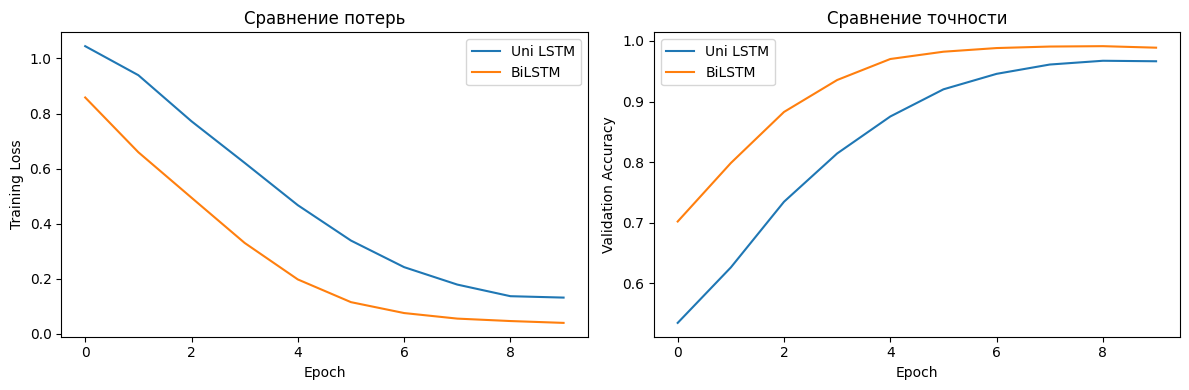

In [36]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(uni_loss, label='Uni LSTM')
plt.plot(bi_loss, label='BiLSTM')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.legend()
plt.title('Сравнение потерь')

plt.subplot(1,2,2)
plt.plot(uni_acc, label='Uni LSTM')
plt.plot(bi_acc, label='BiLSTM')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.title('Сравнение точности')
plt.tight_layout()
plt.show()

### **3.1. Визуализация скрытых состояний с помощью t-SNE (3 класса)**

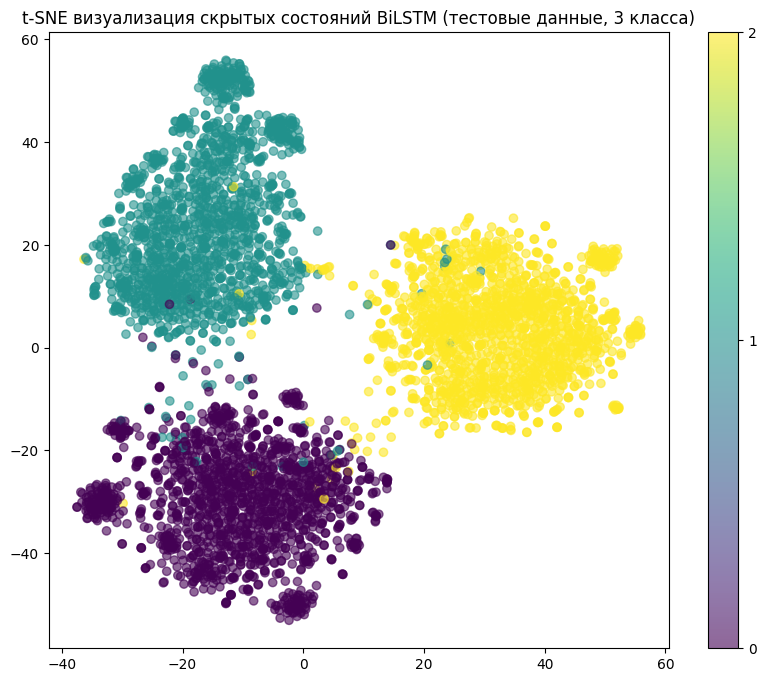

In [37]:
model_bi.eval()
hidden_states = []
labels = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        embedded = model_bi.embedding(X_batch)
        lstm_out, (hidden, _) = model_bi.lstm(embedded)
        if model_bi.lstm.bidirectional:
            hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        else:
            hidden = hidden[-1,:,:]
        hidden_states.append(hidden.cpu().numpy())
        labels.append(y_batch.numpy())

hidden_states = np.vstack(hidden_states)
labels = np.hstack(labels)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
hidden_2d = tsne.fit_transform(hidden_states)

plt.figure(figsize=(10,8))
scatter = plt.scatter(hidden_2d[:,0], hidden_2d[:,1], c=labels, cmap='viridis', alpha=0.6)
plt.colorbar(scatter, ticks=[0,1,2])
plt.title('t-SNE визуализация скрытых состояний BiLSTM (тестовые данные, 3 класса)')
plt.show()

**Задание для интерпретации:**
1. Сравните точность однонаправленной и двунаправленной LSTM. Какая модель оказалась лучше и почему?
2. Посмотрите на t-SNE проекцию. Видны ли кластеры, соответствующие разным классам? Если нет, то что это может означать? Можно ли как-то эту информацию использовать?
3. (Дополнительно) Попробуйте изменить размер скрытого состояния (`hidden_dim`) и количество слоёв LSTM (`n_layers`). Как это влияет на точность и время обучения?

Двунаправленная LSTM показывает лучшую точность и меньшее количество эпох для достижение сравнимой точности из-за того, что слова после целевого слова добавляют больше контекста для классификации

Кластеры видны, значит lstm успешно научиалсь извлекать признаки  

Увеличение скрытого слоя чуть-чуть замедлило обучение и в теории, при увеличенном количестве эпох должно дать более высокую точность

In [38]:
# Параметры
embed_dim = 100
hidden_dim = 256
output_dim = 3  # три класса: neutral, positive, negative

model_uni = LSTMSentiment(vocab_size, embed_dim, hidden_dim, output_dim, bidirectional=False).to(device)
model_bi = LSTMSentiment(vocab_size, embed_dim, hidden_dim, output_dim, bidirectional=True).to(device)

print("Training unidirectional LSTM...")
uni_loss, uni_acc = train_sentiment(model_uni, train_loader, val_loader, epochs=10)

print("\nTraining bidirectional LSTM...")
bi_loss, bi_acc = train_sentiment(model_bi, train_loader, val_loader, epochs=10)

Training unidirectional LSTM...


Epoch 1/10: 100%|██████████| 754/754 [00:04<00:00, 156.37it/s, loss=1.04] 


Epoch 1: avg_train_loss=1.0208, val_acc=0.6123


Epoch 2/10: 100%|██████████| 754/754 [00:04<00:00, 155.23it/s, loss=0.698]


Epoch 2: avg_train_loss=0.9473, val_acc=0.6123


...

Epoch 8: avg_train_loss=0.0479, val_acc=0.9927


Epoch 9/10: 100%|██████████| 754/754 [00:05<00:00, 137.25it/s, loss=0.0447] 


Epoch 9: avg_train_loss=0.0416, val_acc=0.9890


Epoch 10/10: 100%|██████████| 754/754 [00:05<00:00, 137.84it/s, loss=0.126]  


Epoch 10: avg_train_loss=0.0360, val_acc=0.9911


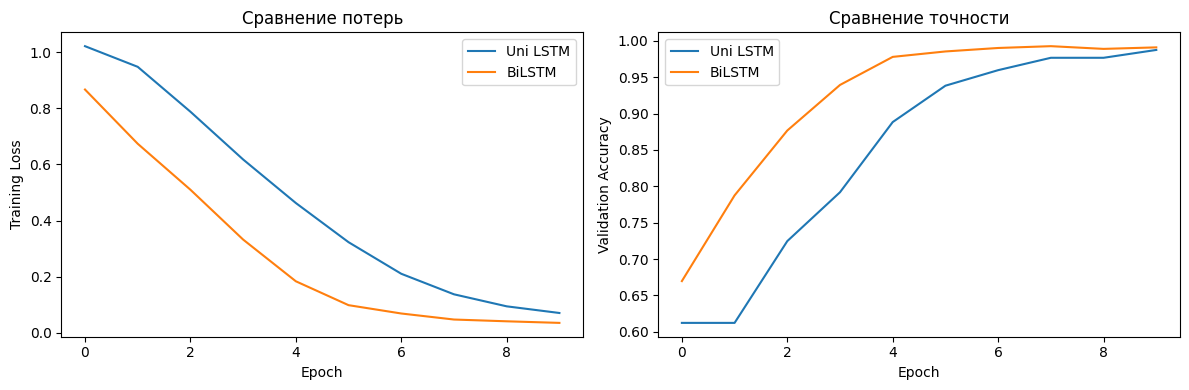

In [39]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(uni_loss, label='Uni LSTM')
plt.plot(bi_loss, label='BiLSTM')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.legend()
plt.title('Сравнение потерь')

plt.subplot(1,2,2)
plt.plot(uni_acc, label='Uni LSTM')
plt.plot(bi_acc, label='BiLSTM')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.title('Сравнение точности')
plt.tight_layout()
plt.show()

## **Заключение**

В этом практическом занятии мы:
- Убедились, что LSTM и GRU значительно лучше справляются с долгосрочными зависимостями, чем vanilla RNN.
- Визуализировали градиенты и увидели, что в RNN они быстро затухают.
- Применили BiLSTM для классификации русскоязычных текстов и сравнили с однонаправленной версией.
- Использовали t-SNE для визуализации скрытых представлений.

Попробуйте поэкспериментировать с гиперпараметрами и, возможно, применить предобученные эмбеддинги (FastText) для улучшения качества.

* Что нового узнали? Навыки/умения/знания.
* Обратная связь: что изменить по наполнению блокнотов материалам или способу подачи материала?